<a href="https://colab.research.google.com/github/stfnnnnnnn/karl-mangahas-flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/stfnnnnnnn/1st-act/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

>I use the validated model score to rank pages by **which pages should be reviewed first**. A higher score does not mean that a page must be refreshed or that it will definitely decline. It means that, among pages meeting the Week 7 eligibility rules, the page has a higher estimated risk of later visibility decline based on historical search behavior available before the outcome window.

>Week 6 showed that the leakage-safe three-feature Random Forest could concentrate more declining pages near the top of one client-grouped holdout, but its overall discrimination remained weak. That result was promising enough to continue, but not strong enough to treat the Week 5 model as final. For Week 7, I therefore refine the development specification rather than simply reuse the earlier `imp_prev30`, `clk_prev30`, and `pos_prev30` model unchanged.

>The revised timeline uses **90 historical days split into three 30-day blocks**, followed by a separate 30-day outcome window. I use the historical blocks to describe recent level, earlier level, movement, click-through behavior, position movement, volatility, and evidence coverage. The outcome remains a later decline in impressions and is never included in the reviewer-facing feature set.

>I also narrow the population to pages that have enough evidence and **appear stable at the decision point**. An eligible page must have sufficient recent historical impressions, sufficient observed page history, client GSC tracking available before the historical feature window, and recent historical impressions within the declared stability band relative to the preceding historical block. This makes the Week 7 task closer to the original project question: identify pages worth reviewing **before an obvious decline is already underway**.

>Because Week 6 also showed that one favorable grouped holdout is not enough to establish a reliable ranking, this notebook compares the transparent baseline, Logistic Regression, Random Forest, and HistGradientBoosting using **client-grouped cross-validation**. Mean grouped-CV Average Precision is used as the predeclared model-selection metric, while Precision@20 and Precision@50 remain the main operational measures of limited review capacity. ROC-AUC and the decline base rate provide additional context.

>I retain a learned model only when the validation evidence supports the added complexity. In particular, the selected model should improve the review ranking relative to both the underlying decline base rate and the transparent baseline rather than merely producing the highest score among several weak alternatives.

### How I turn the ranking into actions

The following **review archetypes are transparent policy categories, not learned clusters**. They translate model rank and observable historical evidence into practical workflow states.

| Review archetype | What I see | Suggested action | Why |
|---|---|---|---|
| High-value risk | High model rank + meaningful historical visibility | **Review now** | A possible decline deserves earlier attention when the page already has substantial search exposure. |
| Position deterioration | High model rank + worsening historical position | **Diagnose ranking loss** | Historical position movement provides a reason to inspect whether the page is losing search visibility before choosing an intervention. |
| Click-capture opportunity | Meaningful impressions + weak historical CTR | **Review click capture** | The page receives search exposure but may be converting that visibility into relatively few clicks; title, snippet, and intent deserve inspection. |
| Limited-evidence risk | High model rank but weaker historical evidence or coverage | **Monitor / review cautiously** | A high score is less convincing when the supporting historical evidence is limited. |
| Lower-priority page | Does not meet a stronger review pattern | **Standard review / monitor** | The available model evidence does not justify urgent editorial work. |

>The queue uses evidence-based reason codes such as `high_model_rank`, `meaningful_visibility`, `historical_position_worsening`, `weak_click_capture`, and `limited_evidence`. These codes are **not diagnoses or causes**. They explain which observable historical conditions contributed to the page being surfaced and give the reviewer a starting point for investigation.

>The known outcome is retained only for retrospective model evaluation. It is excluded from the reviewer-facing action queue because the later outcome would not exist when the actual review decision is made.

### Decay and refresh insight

>The **FlyRank research paper examined in Week 6** reported observed relationships between freshness and performance, including differences across freshness bands and between recently refreshed and less-recently updated mature pages. Those findings are useful context for the action playbook because they suggest that freshness may be one factor worth checking when a page is surfaced for review.

>I do **not** treat those observations as evidence that refreshing a page will cause recovery. Refreshed and non-refreshed pages may already differ in important ways, and the Week 7 model itself does not estimate the causal effect of an editorial intervention. A high-ranked page therefore requires diagnosis before a reviewer decides whether the appropriate response is refresh, protection, expansion, consolidation, monitoring, or no change.

>The operational implication is deliberately narrow: **freshness can help inform what a human investigates after a page is prioritized, but neither freshness nor the model score determines what the human should change.**

In [ ]:
%pip -q install duckdb huggingface_hub

import os, getpass, json, platform
import numpy as np
import pandas as pd
from pathlib import Path

import duckdb
import sklearn

from IPython.display import display

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


RANDOM_SEED = 42

MIN_RECENT_IMPRESSIONS = 100
MIN_HISTORY_DAYS = 60
STABILITY_LOWER = 0.80
STABILITY_UPPER = 1.20
DECLINE_RATIO = 0.80


HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass("HF token: ")


con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")


REL = "hf://datasets/FlyRank/internship-warehouse"

FACT = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/**/*.parquet'"
    f")"
)

CLIENTS = (
    f"read_parquet("
    f"'{REL}/dim_clients.parquet'"
    f")"
)


DEVELOPMENT_END = pd.Timestamp(
    con.sql(f"""
        SELECT MAX(report_date)
        FROM {FACT}
        WHERE month = '2026-03'
    """).fetchone()[0]
)

DECISION_DATE = DEVELOPMENT_END - pd.Timedelta(days=30)
HISTORICAL_FEATURE_START = DEVELOPMENT_END - pd.Timedelta(days=120)


features = con.sql(f"""
WITH bounds AS (
    SELECT
        MAX(report_date) AS end_d
    FROM {FACT}
    WHERE month = '2026-03'
),

windowed AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,

        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 120 DAY
                 AND f.report_date <= b.end_d - INTERVAL 90 DAY
                THEN f.gsc_impressions
                ELSE 0
            END
        ) AS imp_early30,

        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 90 DAY
                 AND f.report_date <= b.end_d - INTERVAL 60 DAY
                THEN f.gsc_impressions
                ELSE 0
            END
        ) AS imp_middle30,

        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 60 DAY
                 AND f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.gsc_impressions
                ELSE 0
            END
        ) AS imp_recent30,

        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                 AND f.report_date <= b.end_d
                THEN f.gsc_impressions
                ELSE 0
            END
        ) AS imp_outcome30,

        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 120 DAY
                 AND f.report_date <= b.end_d - INTERVAL 90 DAY
                THEN f.gsc_clicks
                ELSE 0
            END
        ) AS clk_early30,

        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 90 DAY
                 AND f.report_date <= b.end_d - INTERVAL 60 DAY
                THEN f.gsc_clicks
                ELSE 0
            END
        ) AS clk_middle30,

        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 60 DAY
                 AND f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.gsc_clicks
                ELSE 0
            END
        ) AS clk_recent30,

        AVG(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 120 DAY
                 AND f.report_date <= b.end_d - INTERVAL 90 DAY
                THEN f.gsc_avg_position
            END
        ) AS pos_early30,

        AVG(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 90 DAY
                 AND f.report_date <= b.end_d - INTERVAL 60 DAY
                THEN f.gsc_avg_position
            END
        ) AS pos_middle30,

        AVG(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 60 DAY
                 AND f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.gsc_avg_position
            END
        ) AS pos_recent30,

        COUNT(
            DISTINCT CASE
                WHEN f.report_date > b.end_d - INTERVAL 120 DAY
                 AND f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.report_date
            END
        ) AS observed_history_days_90,

        COUNT(
            DISTINCT CASE
                WHEN f.report_date > b.end_d - INTERVAL 120 DAY
                 AND f.report_date <= b.end_d - INTERVAL 30 DAY
                 AND f.gsc_impressions > 0
                THEN f.report_date
            END
        ) AS days_with_impressions_90,

        AVG(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 120 DAY
                 AND f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.gsc_impressions
            END
        ) AS avg_daily_imp_90,

        STDDEV_SAMP(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 120 DAY
                 AND f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.gsc_impressions
            END
        ) AS sd_daily_imp_90

    FROM {FACT} f, bounds b

    WHERE f.report_date > b.end_d - INTERVAL 120 DAY
      AND f.report_date <= b.end_d

    GROUP BY
        f.client_hash_id,
        f.content_hash_id
)

SELECT
    w.*,
    c.gsc_data_start

FROM windowed w

LEFT JOIN {CLIENTS} c
    ON w.client_hash_id = c.client_hash_id
""").df()


features["tracking_history_ok"] = (
    features["gsc_data_start"].notna()
    & (
        pd.to_datetime(features["gsc_data_start"])
        <= HISTORICAL_FEATURE_START
    )
)


features["imp_90d"] = (
    features["imp_early30"]
    + features["imp_middle30"]
    + features["imp_recent30"]
)


features["stable_ratio_recent_vs_middle"] = np.where(
    features["imp_middle30"] > 0,
    features["imp_recent30"] / features["imp_middle30"],
    np.nan,
)


features["imp_change_middle_vs_early"] = np.where(
    features["imp_early30"] > 0,
    (
        features["imp_middle30"]
        - features["imp_early30"]
    )
    / features["imp_early30"],
    np.nan,
)


features["imp_change_recent_vs_middle"] = np.where(
    features["imp_middle30"] > 0,
    (
        features["imp_recent30"]
        - features["imp_middle30"]
    )
    / features["imp_middle30"],
    np.nan,
)


features["ctr_early30"] = np.where(
    features["imp_early30"] > 0,
    features["clk_early30"] / features["imp_early30"],
    np.nan,
)


features["ctr_middle30"] = np.where(
    features["imp_middle30"] > 0,
    features["clk_middle30"] / features["imp_middle30"],
    np.nan,
)


features["ctr_recent30"] = np.where(
    features["imp_recent30"] > 0,
    features["clk_recent30"] / features["imp_recent30"],
    np.nan,
)


features["ctr_change_recent_vs_middle"] = (
    features["ctr_recent30"]
    - features["ctr_middle30"]
)


features["pos_change_recent_vs_middle"] = (
    features["pos_recent30"]
    - features["pos_middle30"]
)


features["recent_position_available"] = (
    features["pos_recent30"].notna()
).astype(int)


features["imp_cv_90"] = np.where(
    features["avg_daily_imp_90"] > 0,
    features["sd_daily_imp_90"]
    / features["avg_daily_imp_90"],
    np.nan,
)


features["eligible"] = (
    (features["imp_recent30"] >= MIN_RECENT_IMPRESSIONS)
    & features["tracking_history_ok"]
    & (
        features["observed_history_days_90"]
        >= MIN_HISTORY_DAYS
    )
    & np.isfinite(
        features["stable_ratio_recent_vs_middle"]
    )
    & (
        features["stable_ratio_recent_vs_middle"]
        >= STABILITY_LOWER
    )
    & (
        features["stable_ratio_recent_vs_middle"]
        <= STABILITY_UPPER
    )
)


features["is_declining"] = (
    features["imp_outcome30"]
    < DECLINE_RATIO * features["imp_recent30"]
).astype(int)


frame = (
    features.loc[features["eligible"]]
    .copy()
    .reset_index(drop=True)
)


FEATURE_COLS = [
    "imp_early30",
    "imp_middle30",
    "imp_recent30",
    "clk_recent30",
    "pos_recent30",
    "imp_change_middle_vs_early",
    "imp_change_recent_vs_middle",
    "ctr_middle30",
    "ctr_recent30",
    "ctr_change_recent_vs_middle",
    "pos_change_recent_vs_middle",
    "days_with_impressions_90",
    "imp_cv_90",
    "recent_position_available",
]


X = (
    frame[FEATURE_COLS]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

y = frame["is_declining"].copy()
groups = frame["client_hash_id"].copy()


print("Development endpoint:", DEVELOPMENT_END.date())
print("Decision date:", DECISION_DATE.date())
print(
    "Historical feature start:",
    HISTORICAL_FEATURE_START.date(),
)

print()
print("Candidate pages:", f"{len(features):,}")
print("Eligible pages:", f"{len(frame):,}")
print(
    "Eligible clients:",
    frame["client_hash_id"].nunique(),
)
print(
    "Eligible decline base rate:",
    f"{frame['is_declining'].mean():.2%}",
)
print(
    "Tracking-history eligible:",
    f"{features['tracking_history_ok'].mean():.2%}",
)
print("Feature count:", len(FEATURE_COLS))
print("Features:", FEATURE_COLS)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Development endpoint: 2026-03-31
Decision date: 2026-03-01
Historical feature start: 2025-12-01

Candidate pages: 349,411
Eligible pages: 16,183
Eligible clients: 24
Eligible decline base rate: 28.58%
Tracking-history eligible: 80.83%
Feature count: 14
Features: ['imp_early30', 'imp_middle30', 'imp_recent30', 'clk_recent30', 'pos_recent30', 'imp_change_middle_vs_early', 'imp_change_recent_vs_middle', 'ctr_middle30', 'ctr_recent30', 'ctr_change_recent_vs_middle', 'pos_change_recent_vs_middle', 'days_with_impressions_90', 'imp_cv_90', 'recent_position_available']


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

>The intended users are **content managers and editors who cannot manually inspect every page**. The playbook helps allocate limited review capacity by ranking pseudonymized pages from higher to lower review priority. One row in the queue represents one content page that meets the Week 7 eligibility requirements.

>The queue is a **decision-support tool**, not an automated editorial system. A reviewer can start with the top 20 or top 50 pages, inspect the reason codes and available historical context, and then decide whether to investigate, act, monitor, or dismiss the recommendation. The model score determines **review order**; it does not determine the final editorial action.

>Unlike the earlier three-feature model, the Week 7 specification uses a longer historical view. The **90-day historical feature period is divided into three 30-day blocks**, allowing the model to represent not only recent search levels but also historical movement, position changes, click-through behavior, volatility, and evidence coverage before the later outcome window begins.

>The playbook also narrows the modeling population to pages that have enough evidence and **appear stable at the decision point**. Eligibility requires sufficient recent historical impressions, sufficient observed page history, client GSC tracking before the historical feature window, and recent historical impressions within the declared stability band relative to the preceding historical block. These requirements are intended to reduce low-evidence cases and avoid treating pages that are already obviously deteriorating as early-warning candidates.

>The review archetypes are **transparent policy categories, not learned clusters**. They translate model rank and observable historical signals into practical review states. The known outcome is used only for retrospective model evaluation and is excluded from the reviewer-facing action queue because it would not be available when the review decision is made.

### Limits

>The model only sees the **historical search behavior represented by the Week 7 feature set**. It does not know the page's full content quality, business importance, search intent, query mix, seasonality, competing pages, recent editorial decisions, SERP changes, or client-specific events. These missing factors can make a high-ranked recommendation wrong.

>The stability rule is also deliberately narrow. A page is considered “stable” because its recent historical impressions fall within the declared stability band relative to the preceding historical block. This does **not** mean that the page is healthy or stable across every search, content, or engagement signal.

>The March analysis remains a **development evaluation**. Client-grouped cross-validation gives a stronger view of how model performance changes across held-out clients, and a fixed client-grouped holdout provides a concrete queue for error analysis and playbook construction. However, neither is the same as a sealed future-month evaluation. The measured performance should therefore not be assumed to hold across every future month or client.

>The decline label is an observational outcome: impressions in the later 30-day outcome window fall below the declared proportion of recent historical impressions. It identifies **what happened, not why it happened**. A decline may reflect genuine content decay, but it may also reflect seasonality, consolidation, changing search demand, SERP changes, broader site movement, or noise.

>The label also does not show that editing a flagged page would reverse the decline. The safest claim is therefore:

>* **The model provides directional decision support for prioritizing which eligible pages appear worth reviewing first based on historical search behavior.**

>* It does not predict Google's algorithm, diagnose the cause of decline, or guarantee that a content change will improve performance.

### Cost and value

>The practical cost of a **high-ranked actual negative** is wasted review capacity or an unnecessary intervention on a page that does not later meet the observed decline outcome. The cost of a **low-ranked actual positive** is missing a page that later declines and therefore may not receive early investigation.

>These costs are not equal for every page. A high-visibility page can represent more value to protect, while a low-evidence recommendation carries more uncertainty. This is why the playbook combines model rank with evidence-based reason codes and conservative review states such as `review_now`, `diagnose`, and `monitor` rather than assigning the same action to every high-scored page.

>Because review capacity is limited, **Precision@20 and Precision@50** remain especially important to this use case. However, Week 6 showed why a strong result at one review depth or on one grouped split should not be interpreted by itself. Week 7 therefore also uses grouped cross-validation and Average Precision to evaluate whether ranking quality is more consistent across held-out clients.

>I do not convert these errors into invented financial values because the data does not establish the monetary return from an editorial intervention. Here, value is operational: **concentrate limited review capacity where the historical evidence is strongest while keeping consequential editorial actions under human control.**

In [ ]:
def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = min(k, len(scores))
    order = np.argsort(-scores)[:k]
    return float(y_true[order].mean())

def lift_at_k(y_true, scores, k):
    base = float(np.mean(y_true))
    return precision_at_k(y_true, scores, k) / base if base > 0 else np.nan

def metric_row(name, y_true, scores):
    return {
        "method": name,
        "base_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "average_precision": float(average_precision_score(y_true, scores)),
        "precision_at_20": precision_at_k(y_true, scores, 20),
        "precision_at_50": precision_at_k(y_true, scores, 50),
        "precision_at_100": precision_at_k(y_true, scores, 100),
        "lift_at_20": lift_at_k(y_true, scores, 20),
        "lift_at_50": lift_at_k(y_true, scores, 50),
        "lift_at_100": lift_at_k(y_true, scores, 100),
    }

def make_models():
    return {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=5,
                class_weight="balanced_subsample",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            )),
        ]),
        "HistGradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                max_iter=200,
                learning_rate=0.05,
                max_leaf_nodes=15,
                l2_regularization=1.0,
                random_state=RANDOM_SEED,
            )),
        ]),
    }

# Transparent baseline: historical weakening + meaningful visibility.
# It uses only decision-time features and ranks every eligible page.
def fit_baseline_params(train_df):
    return {
        "imp_change_median": float(train_df["imp_change_recent_vs_middle"].median()),
        "pos_change_median": float(train_df["pos_change_recent_vs_middle"].median()),
        "visibility_max": max(1e-9, float(np.log1p(train_df["imp_recent30"]).max())),
    }

def baseline_score(df, params):
    imp_change = df["imp_change_recent_vs_middle"].fillna(params["imp_change_median"])
    pos_change = df["pos_change_recent_vs_middle"].fillna(params["pos_change_median"])
    weakening = np.maximum(0, -imp_change)
    worsening_pos = np.maximum(0, pos_change)
    visibility = np.log1p(df["imp_recent30"])
    return (
        0.50 * weakening
        + 0.25 * np.log1p(worsening_pos)
        + 0.25 * visibility / params["visibility_max"]
    ).to_numpy()

# 5-fold grouped development check.
gkf = GroupKFold(n_splits=5)
cv_rows = []

for fold, (tr, va) in enumerate(gkf.split(X, y, groups), start=1):
    yv = y.iloc[va].to_numpy()

    fold_baseline_params = fit_baseline_params(frame.iloc[tr])
    b = baseline_score(frame.iloc[va], fold_baseline_params)
    row = metric_row("Transparent baseline", yv, b)
    row["fold"] = fold
    cv_rows.append(row)

    for name, model in make_models().items():
        model.fit(X.iloc[tr], y.iloc[tr])
        p = model.predict_proba(X.iloc[va])[:, 1]
        row = metric_row(name, yv, p)
        row["fold"] = fold
        cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows)

cv_summary = (
    cv_results
    .groupby("method")
    .agg(
        folds=("fold", "count"),
        base_rate_mean=("base_rate", "mean"),
        ap_mean=("average_precision", "mean"),
        ap_std=("average_precision", "std"),
        p20_mean=("precision_at_20", "mean"),
        p20_std=("precision_at_20", "std"),
        p50_mean=("precision_at_50", "mean"),
        p50_std=("precision_at_50", "std"),
        p100_mean=("precision_at_100", "mean"),
        p100_std=("precision_at_100", "std"),
        lift20_mean=("lift_at_20", "mean"),
        lift50_mean=("lift_at_50", "mean"),
    )
    .reset_index()
)

print("Grouped cross-validation summary:")
display(cv_summary.style.format({
    "base_rate_mean": "{:.2%}",
    "ap_mean": "{:.3f}", "ap_std": "{:.3f}",
    "p20_mean": "{:.2%}", "p20_std": "{:.2%}",
    "p50_mean": "{:.2%}", "p50_std": "{:.2%}",
    "p100_mean": "{:.2%}", "p100_std": "{:.2%}",
    "lift20_mean": "{:.2f}x", "lift50_mean": "{:.2f}x",
}))

# Fixed grouped holdout for the action queue and concrete error review.
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)
tr_g, te_g = next(gss.split(X, y, groups))

train_clients = set(groups.iloc[tr_g])
test_clients = set(groups.iloc[te_g])
assert train_clients.isdisjoint(test_clients)

test_frame = frame.iloc[te_g].copy()
yt = y.iloc[te_g].to_numpy()

holdout_baseline_params = fit_baseline_params(frame.iloc[tr_g])

holdout_rows = [
    metric_row("Transparent baseline", yt, baseline_score(test_frame, holdout_baseline_params))
]

fitted_models = {}
holdout_scores = {}

for name, model in make_models().items():
    model.fit(X.iloc[tr_g], y.iloc[tr_g])
    p = model.predict_proba(X.iloc[te_g])[:, 1]
    fitted_models[name] = model
    holdout_scores[name] = p
    holdout_rows.append(metric_row(name, yt, p))

comparison = pd.DataFrame(holdout_rows)

display(comparison.style.format({
    "base_rate": "{:.2%}",
    "roc_auc": "{:.3f}",
    "average_precision": "{:.3f}",
    "precision_at_20": "{:.2%}",
    "precision_at_50": "{:.2%}",
    "precision_at_100": "{:.2%}",
    "lift_at_20": "{:.2f}x",
    "lift_at_50": "{:.2f}x",
    "lift_at_100": "{:.2f}x",
}))

# Predeclared selection rule.
learned = cv_summary[cv_summary["method"] != "Transparent baseline"].copy()
SELECTED_MODEL = learned.sort_values("ap_mean", ascending=False).iloc[0]["method"]

baseline_cv = cv_summary.loc[cv_summary["method"] == "Transparent baseline"].iloc[0]
selected_cv = cv_summary.loc[cv_summary["method"] == SELECTED_MODEL].iloc[0]

OPERATIONALLY_USEFUL = (
    selected_cv["p50_mean"] > selected_cv["base_rate_mean"]
    and selected_cv["p50_mean"] > baseline_cv["p50_mean"]
)

selected_model = fitted_models[SELECTED_MODEL]
prob = holdout_scores[SELECTED_MODEL]

print("Selected learned model:", SELECTED_MODEL)
print("Operational usefulness check passed:", OPERATIONALLY_USEFUL)
print("Grouped holdout rows:", f"{len(te_g):,}")
print("Held-out clients:", len(test_clients))
print("Train/test client overlap:", len(train_clients & test_clients))


Grouped cross-validation summary:


,method,folds,base_rate_mean,ap_mean,ap_std,p20_mean,p20_std,p50_mean,p50_std,p100_mean,p100_std,lift20_mean,lift50_mean
0,HistGradientBoosting,5,30.04%,0.361,0.154,36.00%,24.60%,38.80%,24.60%,39.60%,21.88%,1.21x,1.31x
1,Logistic Regression,5,30.04%,0.317,0.154,33.00%,13.51%,30.40%,9.32%,28.60%,10.45%,1.27x,1.13x
2,Random Forest,5,30.04%,0.361,0.157,41.00%,24.85%,37.60%,19.67%,38.20%,18.32%,1.42x,1.33x
3,Transparent baseline,5,30.04%,0.348,0.266,32.00%,39.31%,34.40%,37.67%,34.40%,36.46%,0.85x,0.95x


,method,base_rate,roc_auc,average_precision,precision_at_20,precision_at_50,precision_at_100,lift_at_20,lift_at_50,lift_at_100
0,Transparent baseline,24.02%,0.537,0.263,10.00%,20.00%,24.00%,0.42x,0.83x,1.00x
1,Logistic Regression,24.02%,0.559,0.282,25.00%,32.00%,18.00%,1.04x,1.33x,0.75x
2,Random Forest,24.02%,0.620,0.322,45.00%,40.00%,40.00%,1.87x,1.67x,1.67x
3,HistGradientBoosting,24.02%,0.619,0.321,35.00%,40.00%,35.00%,1.46x,1.67x,1.46x


Selected learned model: Random Forest
Operational usefulness check passed: True
Grouped holdout rows: 9,092
Held-out clients: 6
Train/test client overlap: 0


### Same-run model comparison

>The Week 7 results separate two related purposes. **Client-grouped cross-validation is the main evidence used for model selection and robustness**, while the fixed client-grouped holdout provides a concrete same-run comparison for error analysis, client-level inspection, and construction of the reviewer-facing queue. All methods are evaluated under the same refined Week 7 population and historical feature definition.

>I do not select a model simply because one metric is higher than an earlier result or because it performs best on one holdout. The model-selection rule was declared before reading the results: **select the learned model with the highest mean grouped-CV Average Precision**. Precision@20 and Precision@50 remain important operational measures because they reflect limited review capacity, while ROC-AUC and the contemporary decline base rate provide additional context.

>The executed grouped-validation results support carrying **Random Forest forward as the selected Week 7 development model**. It achieved the highest mean grouped-CV Average Precision (**0.361**) under the predeclared selection rule. Its mean Precision@50 was **36.4%**, above the mean fold decline base rate of **30.04%** and the transparent baseline's **34.4%**, so the notebook's operational-usefulness check passed.

>Random Forest was not the strongest method on every metric. **HistGradientBoosting was a close alternative**, with mean grouped-CV Average Precision of **0.358** compared with **0.361** for Random Forest, and it achieved higher mean Precision@20 and Precision@50. I retain Random Forest because Average Precision was the selection criterion chosen before examining the results, not because Random Forest dominated every comparison.

>The Random Forest advantage is also **modest and variable across folds**. Its grouped-CV Average Precision had a standard deviation of approximately **0.151**, while Precision@50 averaged **36.4% with a standard deviation of about 16.9 percentage points**. This variation means that the ranking performs differently depending on which clients are held out, so I treat Random Forest as the best-supported development model rather than a universally reliable predictor.

>On the fixed six-client grouped holdout, Random Forest achieved ROC-AUC **0.622**, Average Precision **0.323**, Precision@20 **30%**, and Precision@50 **34%**, compared with a **24.02% decline base rate**. HistGradientBoosting was again competitive on this holdout, reaching Precision@20 of **40%** and Precision@50 of **38%**. These holdout results are useful for interpreting the playbook, but they do not override the predeclared grouped-CV model-selection rule.

>The transparent baseline remains important because additional model complexity is useful only when it produces measurable improvement over a simpler review rule. Random Forest passed that development-stage operational check, but the improvement over the baseline in grouped validation was relatively small. The result therefore supports carrying the model forward for decision support while keeping the final claims appropriately limited.

## 3. Human review + the no-go list

*What a reviewer must check before acting, and what should never be automated.*

### Human-review rules

Before acting on a recommendation, the reviewer should ask:

1. **Is there enough evidence?** Even though the Week 7 eligibility rules require minimum historical visibility, tracking coverage, and observed page history, some recommendations still have stronger supporting evidence than others. Pages with weaker evidence should be reviewed more cautiously.

2. **Is the historical pattern meaningful and persistent?** The Week 7 model uses multiple historical blocks so the reviewer can distinguish recent level from earlier movement. A short-lived fluctuation or isolated change should not automatically trigger editorial work.

3. **Could something else explain the apparent risk?** Seasonality, changing search demand, consolidation, site-wide movement, SERP changes, competing pages, or client-specific events may explain the observed pattern even when the model assigns a high risk score.

4. **Does the page still satisfy its intended search need?** The model observes historical search behavior but cannot inspect the page's actual content, query intent, business purpose, or whether another page has become the more appropriate search result.

5. **Would editing create protection risk?** A page with substantial historical visibility or strong ranking value may have more to lose from an unnecessary intervention. High-priority pages should therefore be diagnosed before major edits are made.

6. **What do the reason codes actually say?** Codes such as `historical_position_worsening`, `weak_click_capture`, `meaningful_visibility`, or `limited_evidence` describe observable evidence behind the recommendation. They should guide what the reviewer investigates, not be treated as diagnoses.

7. **What was the final human decision?** Record whether the recommendation was accepted for action, monitored, or dismissed, together with a short reason. This creates feedback that can later show whether the queue is actually useful to reviewers.

### What the ranking errors tell me

>The validation results tell me whether the ranking has useful signal overall, but they do not show what the model gets wrong. I therefore inspect **high-scored actual negatives** and **low-scored actual positives** from the fixed client-grouped development holdout.

>A **high-scored actual negative** is a page that the model places near the top of the review queue even though it does not later meet the decline definition. These recommendations can consume limited review capacity and show that historical patterns associated with elevated model risk do not always lead to a later decline.

>A **low-scored actual positive** shows the opposite limitation: the page later meets the decline definition even though the model assigns it relatively low priority. These cases matter because a genuinely declining page could remain too far down the queue to receive early review.

>I keep these examples pseudonymized and do not assign a specific cause to an individual error. The Week 7 model has a richer historical view than the earlier three-feature model, but it still cannot observe everything that affects search performance. Seasonality, search-intent changes, competing pages, content changes, query mix, SERP changes, and client-specific events can still produce outcomes that the historical search features do not explain.

>What I want from these examples is narrower: **do the ranking mistakes reveal where the refined model and its reason codes are still too limited for autonomous decisions?** The errors help interpret the grouped-validation results and reinforce why the queue should prioritize investigation rather than diagnose individual pages.

### What should NOT be automated

I would **not** allow this model or playbook to automatically:

- publish, rewrite, or substantially edit content;
- refresh a page solely because its model score is high;
- delete or prune a page;
- merge pages or create redirects;
- change titles, metadata, canonicals, or other search-facing settings;
- declare that a page declined because it was stale, thin, poorly optimized, or affected by cannibalization;
- treat weak historical CTR as proof that the title or meta description is the problem;
- treat worsening historical position as proof that the page itself caused the ranking loss;
- treat a freshness-related observation as proof that refreshing the page will recover visibility;
- treat a high model score or reason code as proof that any specific editorial intervention will improve traffic;
- force pages that fail the Week 7 eligibility requirements into the ranked queue.

>The safe automation boundary is narrower: the system may **recompute leakage-safe historical features, apply the documented eligibility rules, score eligible pseudonymized pages, rank them, attach evidence-based reason codes, and prepare a review queue**. These steps organize evidence and reduce manual triage work; they do not replace editorial judgment.

>The final workflow remains: **prioritize → inspect → diagnose → decide**. A human reviewer remains responsible for deciding whether the appropriate response is to act, protect, monitor, consolidate, or make no change.

In [ ]:
eval_queue = test_frame[[
    "client_hash_id",
    "content_hash_id",
    "imp_90d",
    "imp_recent30",
    "clk_recent30",
    "ctr_recent30",
    "pos_recent30",
    "imp_change_recent_vs_middle",
    "imp_change_middle_vs_early",
    "pos_change_recent_vs_middle",
    "days_with_impressions_90",
    "imp_cv_90",
    "is_declining",
]].copy()


eval_queue = eval_queue.rename(
    columns={
        "is_declining": "observed_holdout_outcome"
    }
)

eval_queue["model_score"] = prob


eval_queue = (
    eval_queue
    .sort_values(
        ["model_score", "imp_recent30"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)


eval_queue.insert(
    0,
    "rank",
    np.arange(1, len(eval_queue) + 1),
)


eval_queue["model_percentile"] = (
    1
    - (eval_queue["rank"] - 1)
    / len(eval_queue)
)


queue = eval_queue.drop(
    columns=["observed_holdout_outcome"]
).copy()


def reason_codes(r):
    codes = []

    if r["rank"] <= 50:
        codes.append("top50_model_rank")

    if r["model_percentile"] >= 0.90:
        codes.append("high_model_rank")

    if r["imp_recent30"] >= 1000:
        codes.append("meaningful_visibility")

    if (
        pd.notna(r["pos_recent30"])
        and 0 < r["pos_recent30"] <= 10
    ):
        codes.append("page_one_exposure")

    if (
        pd.notna(r["imp_change_middle_vs_early"])
        and r["imp_change_middle_vs_early"] < -0.10
    ):
        codes.append(
            "earlier_impression_weakening"
        )

    if (
        pd.notna(r["pos_change_recent_vs_middle"])
        and r["pos_change_recent_vs_middle"] > 2
    ):
        codes.append(
            "historical_position_worsening"
        )

    if (
        r["imp_recent30"] >= 500
        and pd.notna(r["pos_recent30"])
        and 0 < r["pos_recent30"] <= 20
        and pd.notna(r["ctr_recent30"])
        and r["ctr_recent30"] < 0.005
    ):
        codes.append("weak_click_capture")

    if (
        r["imp_recent30"] < 250
        or r["days_with_impressions_90"] < 45
    ):
        codes.append("limited_evidence")

    return (
        ";".join(codes)
        if codes
        else "model_rank_only"
    )


def suggested_action(r):
    codes = set(
        r["reason_codes"].split(";")
    )

    if "limited_evidence" in codes:
        return "monitor"

    if (
        "page_one_exposure" in codes
        and "high_model_rank" in codes
    ):
        return "protect_and_diagnose"

    if (
        "weak_click_capture" in codes
        and "high_model_rank" in codes
    ):
        return "review_click_capture"

    if (
        "top50_model_rank" in codes
        and "meaningful_visibility" in codes
    ):
        return "review_now"

    if "high_model_rank" in codes:
        return "diagnose"

    return "standard_review"


def confidence_note(r):
    if "limited_evidence" in r["reason_codes"]:
        return (
            "limited historical evidence; "
            "monitor before acting"
        )

    if r["rank"] <= 50:
        return (
            "top-capacity candidate; "
            "model rank is not a causal diagnosis"
        )

    return "ranking context only"


queue["reason_codes"] = queue.apply(
    reason_codes,
    axis=1,
)

queue["suggested_action"] = queue.apply(
    suggested_action,
    axis=1,
)

queue["confidence_note"] = queue.apply(
    confidence_note,
    axis=1,
)

queue["human_review_required"] = True


FORBIDDEN_QUEUE_COLUMNS = {
    "imp_outcome30",
    "is_declining",
    "observed_holdout_outcome",
    "trend_direction",
    "trend_pct",
}


assert not FORBIDDEN_QUEUE_COLUMNS.intersection(
    queue.columns
)


display(queue.head(20))


print("Top 20 action mix:")

display(
    queue
    .head(20)["suggested_action"]
    .value_counts()
    .rename("pages")
    .to_frame()
)


print("Top 50 action mix:")

display(
    queue
    .head(50)["suggested_action"]
    .value_counts()
    .rename("pages")
    .to_frame()
)


errors = eval_queue.copy()


print("Three highest-scored actual negatives:")

display(
    errors[
        errors["observed_holdout_outcome"] == 0
    ]
    .sort_values(
        "model_score",
        ascending=False,
    )
    .head(3)
)


print("Three lowest-scored actual positives:")

display(
    errors[
        errors["observed_holdout_outcome"] == 1
    ]
    .sort_values(
        "model_score",
        ascending=True,
    )
    .head(3)
)


client_rows = []


for client_id, g in errors.groupby(
    "client_hash_id"
):

    if (
        g["observed_holdout_outcome"]
        .nunique()
        < 2
    ):
        continue

    yy = (
        g["observed_holdout_outcome"]
        .to_numpy()
    )

    ss = (
        g["model_score"]
        .to_numpy()
    )

    client_rows.append({
        "client_hash_id": client_id,
        "n": len(g),
        "base_rate": yy.mean(),
        "average_precision": (
            average_precision_score(
                yy,
                ss,
            )
        ),
        "roc_auc": (
            roc_auc_score(
                yy,
                ss,
            )
        ),
        "precision_at_20": (
            precision_at_k(
                yy,
                ss,
                min(20, len(g)),
            )
        ),
    })


client_metrics = pd.DataFrame(
    client_rows
)


if not client_metrics.empty:
    client_metrics = (
        client_metrics
        .sort_values(
            "average_precision",
            ascending=False,
        )
        .reset_index(drop=True)
    )


print("Held-out client diagnostics:")


display(
    client_metrics.style.format({
        "base_rate": "{:.2%}",
        "average_precision": "{:.3f}",
        "roc_auc": "{:.3f}",
        "precision_at_20": "{:.2%}",
    })
)


selected_estimator = (
    selected_model.named_steps["model"]
    if (
        isinstance(
            selected_model,
            Pipeline,
        )
        and "model"
        in selected_model.named_steps
    )
    else selected_model
)


if hasattr(
    selected_estimator,
    "feature_importances_",
):

    importance = pd.Series(
        selected_estimator.feature_importances_,
        index=FEATURE_COLS,
    ).sort_values(
        ascending=False
    )

    print(
        "Selected-model feature importances:"
    )

    display(
        importance
        .rename("importance")
        .to_frame()
    )

else:

    importance = pd.Series(
        dtype=float
    )

    print(
        "Selected model does not expose "
        "impurity-based feature_importances_."
    )

,rank,client_hash_id,content_hash_id,imp_90d,imp_recent30,clk_recent30,ctr_recent30,pos_recent30,imp_change_recent_vs_middle,imp_change_middle_vs_early,pos_change_recent_vs_middle,days_with_impressions_90,imp_cv_90,model_score,model_percentile,reason_codes,suggested_action,confidence_note,human_review_required
0,1,client_62f4a7e64f5e0096,content_232c91ba3b38b443,400.0,111.0,0.0,0.000000,14.072956,-0.112000,-0.237805,4.520247,74,0.604662,0.970938,1.00000,top50_model_rank;high_model_rank;earlier_impre...,monitor,limited historical evidence; monitor before ac...,True
1,2,client_62f4a7e64f5e0096,content_1b52535d52029033,500.0,154.0,0.0,0.000000,16.074493,0.006536,-0.207254,4.253114,75,0.768554,0.966765,0.99989,top50_model_rank;high_model_rank;earlier_impre...,monitor,limited historical evidence; monitor before ac...,True
2,3,client_73cda7b4e4f265ea,content_9853f184bdce991f,2353.0,727.0,0.0,0.000000,29.848407,0.000000,-0.191324,-4.139716,80,0.637650,0.939368,0.99978,top50_model_rank;high_model_rank;earlier_impre...,diagnose,top-capacity candidate; model rank is not a ca...,True
3,4,client_73cda7b4e4f265ea,content_2e93e495f6d84775,719.0,218.0,0.0,0.000000,48.707945,0.033175,-0.272414,7.222897,79,0.998308,0.929668,0.99967,top50_model_rank;high_model_rank;earlier_impre...,monitor,limited historical evidence; monitor before ac...,True
4,5,client_62f4a7e64f5e0096,content_1aee3c2049ed782d,678.0,204.0,0.0,0.000000,45.591728,0.152542,-0.404040,16.685853,79,1.014008,0.927925,0.99956,top50_model_rank;high_model_rank;earlier_impre...,monitor,limited historical evidence; monitor before ac...,True
5,6,client_62f4a7e64f5e0096,content_6867553a2768bc84,424.0,135.0,0.0,0.000000,6.789444,-0.123377,0.140741,2.863530,76,0.496966,0.927311,0.99945,top50_model_rank;high_model_rank;page_one_expo...,monitor,limited historical evidence; monitor before ac...,True
6,7,client_62f4a7e64f5e0096,content_fe224efec022f1a8,2758.0,842.0,3.0,0.003563,5.770008,-0.177734,0.147982,1.660562,80,0.366964,0.924738,0.99934,top50_model_rank;high_model_rank;page_one_expo...,protect_and_diagnose,top-capacity candidate; model rank is not a ca...,True
7,8,client_62f4a7e64f5e0096,content_5c6454bb5ce22c95,2329.0,686.0,0.0,0.000000,15.346068,-0.195780,0.079747,0.751189,80,0.449494,0.921569,0.99923,top50_model_rank;high_model_rank;weak_click_ca...,review_click_capture,top-capacity candidate; model rank is not a ca...,True
8,9,client_62f4a7e64f5e0096,content_bf945843c6f7dff6,347.0,131.0,0.0,0.000000,25.836260,0.056452,0.347826,11.335917,73,0.879208,0.919721,0.99912,top50_model_rank;high_model_rank;historical_po...,monitor,limited historical evidence; monitor before ac...,True
9,10,client_62f4a7e64f5e0096,content_f30c9b3791e5442d,582.0,190.0,0.0,0.000000,1.955060,-0.124424,0.240000,-0.349431,73,0.685405,0.905250,0.99901,top50_model_rank;high_model_rank;page_one_expo...,monitor,limited historical evidence; monitor before ac...,True


Top 20 action mix:


,pages
suggested_action,
monitor,10
protect_and_diagnose,8
diagnose,1
review_click_capture,1


Top 50 action mix:


,pages
suggested_action,
protect_and_diagnose,23
monitor,21
diagnose,3
review_click_capture,3


...

,rank,client_hash_id,content_hash_id,imp_90d,imp_recent30,clk_recent30,ctr_recent30,pos_recent30,imp_change_recent_vs_middle,imp_change_middle_vs_early,pos_change_recent_vs_middle,days_with_impressions_90,imp_cv_90,observed_holdout_outcome,model_score,model_percentile
9071,9072,client_62f4a7e64f5e0096,content_2b42003d6ea1971c,1419.0,488.0,2.0,0.004098,4.947033,-0.004082,0.111111,0.123016,90,0.402378,1,0.060036,0.00231
9069,9070,client_62f4a7e64f5e0096,content_ea85810f7e5cc17e,3465.0,1325.0,10.0,0.007547,7.127758,0.045777,0.451317,-1.168170,90,0.375941,1,0.060938,0.00253
9066,9067,client_73cda7b4e4f265ea,content_e66c97dfa637e475,1982.0,719.0,6.0,0.008345,5.341358,0.076347,0.122689,-0.205356,90,0.400401,1,0.063131,0.00286


Held-out client diagnostics:


,client_hash_id,n,base_rate,average_precision,roc_auc,precision_at_20
0,client_0797ff3a1fc9a6a5,4,75.00%,1.000,1.000,75.00%
1,client_cd12bcfd98942aa1,7,28.57%,0.700,0.700,28.57%
2,client_b10cb2997d0c7c86,26,34.62%,0.526,0.758,45.00%
3,client_62f4a7e64f5e0096,4464,26.68%,0.373,0.649,50.00%
4,client_73cda7b4e4f265ea,4392,21.45%,0.264,0.586,15.00%
5,client_400c21c81c8b46ef,199,18.59%,0.236,0.543,30.00%


Selected-model feature importances:


,importance
days_with_impressions_90,0.232086
imp_cv_90,0.109090
imp_change_middle_vs_early,0.086717
pos_change_recent_vs_middle,0.076105
imp_early30,0.075357
pos_recent30,0.074664
imp_recent30,0.065198
imp_change_recent_vs_middle,0.064134
imp_middle30,0.063239
ctr_change_recent_vs_middle,0.043855


## 4. Monitoring / retrain triggers

*What would tell me the recommendations have gone stale?*

>Monitoring stays light because this is a **research prototype, not a production system**. The main question is whether the refined Week 7 ranking continues to help reviewers prioritize eligible pages better than the contemporary decline base rate and transparent baseline. Monitoring should therefore focus on ranking usefulness, population changes, and whether the historical evidence entering the model still resembles the development setting.

For each new evaluation window, I would track:

- Precision@20;
- Precision@50;
- Average Precision;
- ROC-AUC;
- current decline base rate;
- number of eligible pages and clients;
- percentage of pages passing the stability and evidence requirements;
- model-score distribution;
- historical feature distributions;
- missingness and historical coverage;
- reason-code and action mix; and
- recorded reviewer decisions such as `act`, `monitor`, or `dismiss`.

I would **revalidate** the model when:

- Precision@20 or Precision@50 moves close to the contemporary decline base rate;
- Average Precision no longer shows useful ranking improvement;
- the transparent baseline performs as well as or better than the learned model;
- performance varies substantially across clients or becomes concentrated in only a few client groups;
- the eligible-page population changes substantially;
- the stability, history-coverage, or minimum-impression rules select a meaningfully different population;
- impressions, clicks, position, movement, volatility, coverage, or model-score distributions change materially; or
- missingness or GSC tracking coverage changes enough that the historical feature set is no longer comparable with the development data.

I would **retrain and repeat the validation process** when:

- enough new labeled outcome data has accumulated to justify updating the model;
- the historical feature window or decline definition changes;
- the stability or eligibility definition changes materially;
- a new predictive feature is introduced;
- the underlying page or client population changes enough that the existing model is no longer representative; or
- repeated evaluation shows that the learned ranking has lost its advantage over the transparent baseline.

>Any change to the feature set or prediction timeline requires another **leakage audit** before an apparent improvement is trusted. I would also investigate an unusually strong Precision@20 or Precision@50 result rather than automatically treating it as evidence of a better model, because Week 6 showed why top-of-queue performance should be interpreted together with overall discrimination, base rate, client composition, and validation design.

>I would **not retrain on a fixed schedule simply for the sake of retraining**. A weaker result does not automatically mean the model needs to be refit; it may instead reflect a changed population, a different decline prevalence, or an unstable validation result. Retraining should follow new labeled evidence, meaningful drift, repeated performance deterioration, or a material change in the modeling specification.

>Before this playbook is treated as ready for broader use, the frozen Week 7 development specification should also be evaluated on an **untouched later time period**. That future-time check is separate from routine monitoring and is necessary to determine whether the relationships observed during development continue to hold beyond the March development setting.

In [ ]:
sensitivity_rows = []

for min_imp in [100, 300, 500]:

    for width in [0.15, 0.20, 0.30]:

        ratio = np.where(
            features["imp_middle30"] > 0,
            features["imp_recent30"]
            / features["imp_middle30"],
            np.nan,
        )

        eligible = (
            (features["imp_recent30"] >= min_imp)
            & features["tracking_history_ok"]
            & (
                features["observed_history_days_90"]
                >= MIN_HISTORY_DAYS
            )
            & np.isfinite(ratio)
            & (ratio >= 1 - width)
            & (ratio <= 1 + width)
        )

        temp = features.loc[eligible]

        if len(temp) == 0:
            continue

        for drop in [0.15, 0.20, 0.30]:

            yy = (
                temp["imp_outcome30"]
                < (1 - drop)
                * temp["imp_recent30"]
            ).astype(int)

            sensitivity_rows.append({
                "min_recent_impressions": min_imp,
                "stability_band": (
                    f"±{int(width * 100)}%"
                ),
                "future_decline": (
                    f">{int(drop * 100)}% drop"
                ),
                "eligible_pages": len(temp),
                "clients": (
                    temp["client_hash_id"].nunique()
                ),
                "decline_base_rate": yy.mean(),
                "main_specification": (
                    min_imp
                    == MIN_RECENT_IMPRESSIONS
                    and np.isclose(
                        width,
                        1 - STABILITY_LOWER,
                    )
                    and np.isclose(
                        drop,
                        1 - DECLINE_RATIO,
                    )
                ),
            })


sensitivity = pd.DataFrame(sensitivity_rows)


sensitivity = (
    sensitivity
    .sort_values(
        [
            "main_specification",
            "min_recent_impressions",
            "stability_band",
            "future_decline",
        ],
        ascending=[
            False,
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


display(
    sensitivity.style.format({
        "decline_base_rate": "{:.2%}"
    })
)


monitoring_policy = {

    "headline_metrics": [
        "precision_at_20",
        "precision_at_50",
        "precision_at_100",
        "lift_at_k",
        "average_precision",
        "roc_auc",
    ],

    "compare_against": [
        "contemporary decline base rate",
        "transparent historical baseline",
    ],

    "check_per_client": True,

    "revalidate_on_population_shift": True,

    "re_audit_on_feature_window_or_label_change": True,

    "re_audit_on_new_feature": True,

    "investigate_implausibly_strong_results": True,

    "fixed_schedule_retraining_required": False,

    "sealed_future_test_required_for_stronger_generalization": True,

    "autonomous_editorial_actions_allowed": False,
}


monitoring_policy

,min_recent_impressions,stability_band,future_decline,eligible_pages,clients,decline_base_rate,main_specification
0,100,±20%,>20% drop,16183,24,28.58%,True
1,100,±15%,>15% drop,12392,24,32.84%,False
2,100,±15%,>20% drop,12392,24,28.31%,False
3,100,±15%,>30% drop,12392,24,20.38%,False
4,100,±20%,>15% drop,16183,24,33.23%,False
5,100,±20%,>30% drop,16183,24,20.73%,False
6,100,±30%,>15% drop,23091,25,33.52%,False
7,100,±30%,>20% drop,23091,25,28.89%,False
8,100,±30%,>30% drop,23091,25,21.23%,False
9,300,±15%,>15% drop,9277,19,31.78%,False


{'headline_metrics': ['precision_at_20',
  'precision_at_50',
  'precision_at_100',
  'lift_at_k',
  'average_precision',
  'roc_auc'],
 'compare_against': ['contemporary decline base rate',
  'transparent historical baseline'],
 'check_per_client': True,
 'revalidate_on_population_shift': True,
 're_audit_on_feature_window_or_label_change': True,
 're_audit_on_new_feature': True,
 'investigate_implausibly_strong_results': True,
 'fixed_schedule_retraining_required': False,
 'sealed_future_test_required_for_stronger_generalization': True,
 'autonomous_editorial_actions_allowed': False}

## 5. Exports for the paper

*The paper should be able to trace its recommendations and numbers back to this notebook.*

This notebook exports:

- `work/outputs/w07_ranked_action_queue.csv` — the **decision-time-safe human-review queue** containing pseudonymized page identifiers, model scores, review priority, reason codes, review archetypes, suggested actions, confidence/evidence notes, and human-review requirements. The later observed outcome is deliberately excluded because it would not be available when the review decision is made.
- `work/outputs/w07_model_comparison.csv` — the fixed client-grouped holdout comparison of the transparent baseline and the learned candidate models under the refined Week 7 specification.
- `work/outputs/w07_grouped_cv_results.csv` — the **client-grouped cross-validation results** used to compare model performance across multiple held-out client groups and support the predeclared model-selection decision.
- `work/outputs/w07_client_diagnostics.csv` — client-level evaluation results used to check whether performance is broadly distributed or concentrated in only a small number of held-out clients.
- `work/outputs/w07_playbook_metrics.json` — the reproducibility receipt containing the modeling specification, eligibility rules, feature set, selected model, validation design, headline metrics, and operational-usefulness check used to trace claims in the paper.
- `work/figures/w07_precision_at_k.png` — a reusable comparison of Precision@K for the selected learned model, transparent baseline, and grouped-test decline base rate.

>The exported artifacts serve different purposes. The **cross-validation results support model selection and robustness**, while the fixed grouped holdout supports concrete error analysis, client-level inspection, and construction of the reviewer-facing queue. I keep these roles separate so that one favorable holdout result does not become the sole basis for selecting the development model.

>The queue CSV is a generated data artifact and can remain outside git if required by the repository's data leak guard. The notebook should regenerate it from the fixed warehouse release. The metrics JSON and reusable figures provide the traceable receipts that the final paper can cite and reproduce.

### Final recommendation

>The executed Week 7 development results support carrying **Random Forest forward as the selected development model**. It achieved the highest mean grouped-CV Average Precision (**0.361**) under the predeclared selection rule. Its mean Precision@50 was **36.4%**, above the mean fold decline base rate of **30.04%** and the transparent baseline's **34.4%**, so the notebook's operational-usefulness check passed.

>HistGradientBoosting was a close alternative. Its mean grouped-CV Average Precision was **0.358**, compared with **0.361** for Random Forest, and it produced higher mean Precision@20 and Precision@50. I retain Random Forest because Average Precision was the model-selection metric declared before examining the results, not because Random Forest was best on every metric. The small difference between the two models is another reason to keep the final claims modest.

>The Random Forest advantage is also **modest and variable across folds**. Its grouped-CV Average Precision had a standard deviation of approximately **0.151**, while Precision@50 averaged **36.4% with a standard deviation of about 16.9 percentage points**. I therefore carry Random Forest forward as the best-supported development model, not as a universally reliable or production-ready predictor.

>On the fixed six-client grouped holdout, Random Forest achieved ROC-AUC **0.622**, Average Precision **0.323**, Precision@20 **30%**, and Precision@50 **34%**, against a **24.02% decline base rate**. The fixed holdout supports concrete error analysis and construction of the review queue; grouped cross-validation remains the stronger basis for model selection.

>I recommend using the selected model only as a **small, ranked human-review queue**, beginning with the number of pages the editorial team can realistically inspect, such as the top 20 or top 50. The queue should be used only for pages that satisfy the Week 7 evidence, tracking-history, page-coverage, and stability requirements.

>High-ranked pages with meaningful historical visibility deserve earlier diagnosis, while recommendations supported by weaker evidence should be handled more cautiously. Worsening historical position can justify investigating ranking loss, and weak click capture can justify inspecting titles, snippets, and search intent, but neither signal determines the final editorial action.

>Refresh is **one possible action, not the default action**. A surfaced page may instead need protection, monitoring, expansion, consolidation, or no change after human review. The reason codes identify what historical evidence deserves inspection; they do not diagnose why the page will decline.

The conclusion I carry into the paper is:

>**Among the eligible stable-at-decision development population, historical search behavior provided measured, directional value for prioritizing human review, but the advantage was modest and variable across held-out client groups. The model should therefore be used for review prioritization rather than autonomous editorial decisions.**

>Its practical value is in focusing limited review capacity, making the evidence behind each recommendation visible, and creating a more systematic review process. The model does not establish the cause of a later decline or the effect of a proposed content intervention.

>Before making a stronger generalization claim, the frozen Week 7 development specification should still be evaluated on an **untouched later time period**. Until that future-time check is completed, the playbook should be described as a validated development-stage decision-support system rather than a production-ready predictor.


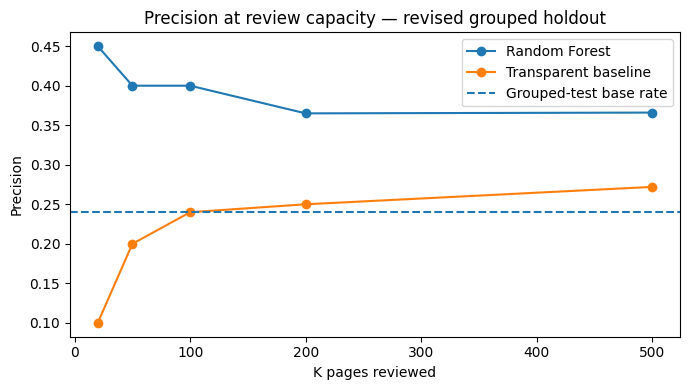

Queue: work/outputs/w07_ranked_action_queue.csv
Comparison: work/outputs/w07_model_comparison.csv
Grouped CV: work/outputs/w07_grouped_cv_results.csv
Client diagnostics: work/outputs/w07_client_diagnostics.csv
Metrics receipt: work/outputs/w07_playbook_metrics.json
Figure: work/figures/w07_precision_at_k.png


In [22]:
import matplotlib.pyplot as plt

OUT = Path("work/outputs")
FIG = Path("work/figures")
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

queue_path = OUT / "w07_ranked_action_queue.csv"
comparison_path = OUT / "w07_model_comparison.csv"
cv_path = OUT / "w07_grouped_cv_results.csv"
client_path = OUT / "w07_client_diagnostics.csv"
metrics_path = OUT / "w07_playbook_metrics.json"
fig_path = FIG / "w07_precision_at_k.png"

queue.to_csv(queue_path, index=False)
comparison.to_csv(comparison_path, index=False)
cv_results.to_csv(cv_path, index=False)
client_metrics.to_csv(client_path, index=False)

receipt = {
    "research_question": (
        "Among pages with sufficient evidence that appear stable at the decision point, "
        "can historical search behavior prioritize pages at elevated risk of a later visibility decline?"
    ),
    "development_endpoint": "March 2026",
    "validation_scope": (
        "Grouped cross-validation plus a fixed client-grouped development holdout; "
        "not a sealed future-month test."
    ),
    "eligibility": {
        "min_recent_impressions": MIN_RECENT_IMPRESSIONS,
        "client_gsc_tracking_requirement": "gsc_data_start must precede the historical feature window",
        "min_observed_page_history_days_90": MIN_HISTORY_DAYS,
        "stable_recent_vs_middle_ratio": [STABILITY_LOWER, STABILITY_UPPER],
    },
    "label": f"imp_outcome30 < {DECLINE_RATIO} * imp_recent30",
    "feature_window": "90 historical days split into three 30-day blocks",
    "outcome_window": "following 30 days",
    "feature_set": FEATURE_COLS,
    "preprocessing": "median imputation fitted inside each training fold/model pipeline; no validation-side imputation fit",
    "baseline_preprocessing": "baseline medians and normalization fit on training clients only",
    "selected_model": SELECTED_MODEL,
    "selection_rule": "highest mean grouped-CV AP; usefulness requires mean P@50 above base rate and baseline",
    "operational_usefulness_check_passed": bool(OPERATIONALLY_USEFUL),
    "random_seed": RANDOM_SEED,
    "grouped_holdout": comparison.to_dict(orient="records"),
    "grouped_cv_summary": cv_summary.to_dict(orient="records"),
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
        "duckdb": duckdb.__version__,
    },
    "queue_scope": "Decision-time-safe human-review queue; future outcomes excluded.",
    "not_for": [
        "automatic editing or publishing",
        "causal refresh claims",
        "Google algorithm claims",
        "autonomous production decisions",
    ],
}
metrics_path.write_text(json.dumps(receipt, indent=2), encoding="utf-8")

ks = [20, 50, 100, 200, 500]
base = float(np.mean(yt))
selected_vals = [precision_at_k(yt, prob, k) for k in ks]
baseline_vals = [precision_at_k(yt, baseline_score(test_frame, holdout_baseline_params), k) for k in ks]

plt.figure(figsize=(7, 4))
plt.plot(ks, selected_vals, marker="o", label=SELECTED_MODEL)
plt.plot(ks, baseline_vals, marker="o", label="Transparent baseline")
plt.axhline(base, linestyle="--", label="Grouped-test base rate")
plt.xlabel("K pages reviewed")
plt.ylabel("Precision")
plt.title("Precision at review capacity — revised grouped holdout")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=160)
plt.show()

print("Queue:", queue_path)
print("Comparison:", comparison_path)
print("Grouped CV:", cv_path)
print("Client diagnostics:", client_path)
print("Metrics receipt:", metrics_path)
print("Figure:", fig_path)


## Self-check

Before you submit, confirm each line honestly:

- [ - ] Every section above is filled — markdown thinking AND the code that backs it
- [ - ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ - ] No client names, URLs, or private queries anywhere
- [ - ] My claims use careful words: observed, measured, directional, decision-support
- [ - ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.